---
title: "DRG Cleaning v2"

author: "Carlos Resurreccion"

date: "2024-10-21"

---


# Parameters

Change which year to process in
`~/drg-pipeline/data-cleaning/00c-year.txt`

Change main GLOBAL (i.e. across all scripts) parameters in 
`~/drg-pipeline/data-cleaning/00a-parameters.r`


Change seldom touched parameters in
`~/drg-pipeline/data-cleaning/r_scripts_v2/0.1.0.params_fpaths.R`

In [ ]:
source(here::here("data-cleaning", "00a-parameters.r"))


# Libraries


In [ ]:
source(here::here("data-cleaning", "00c-packages.r"))


# R Scripts


In [ ]:
source(here::here("data-cleaning", "00d-load-params-and-scripts.r"))


# Data Cleaning Proper


# Load Mapping Data


In [ ]:
source(here::here("data-cleaning", "00e-load-mapping.r"))


# Data Cleaning Function


In [ ]:
# from process_chunk (drg-cleaning)
# Define process_chunk
process_chunk <- function(
    chunk, yr_to_load = year, col_maps = column_mappings,
    known_vals = known_values, remap_master = col_remap_master,
    avail_cols = available_columns,
    looppart = loop_part) {
  fork_id <- Sys.getpid() # Get the process ID
  ##############################################################################
  # 1. Input/Year Standardization
  ##############################################################################
  # Rename Columns
  setnames(chunk,
    old = avail_cols[avail_cols %in% names(col_maps)],
    new = unlist(col_maps[avail_cols[avail_cols %in% names(col_maps)]])
  )

  # Make a copy of clin_c1 and clin_c2 for later use
  # Named list (acts like a dictionary in R)
  mapping <- list(
    "c1" = "clin_c1",
    "c2" = "clin_c2",
    "clin_c1_orig" = "c1",
    "clin_c2_orig" = "c2"
  )

  # Applying the mapping to set values
  for (col in names(mapping)) {
    set(chunk, j = col, value = chunk[[mapping[[col]]]])
  }

  missing_values <- list(
    "id_year" = yr_to_load,
    "pat_bwt" = NA_real_,
    "pat_bdate" = NA_Date_,
    "pat_ageday" = NA_integer_
  )

  for (col in names(missing_values)) {
    if (!col %in% names(chunk)) {
      set(chunk, j = col, value = missing_values[[col]])
    }
  }

  ##############################################################################
  # 2. Reformatting
  ##############################################################################
  ##############################################################################
  # 2.A Cleaning Prerequisites and Type Casting
  ##############################################################################
  if (!to_create_std) {
    # Detect columns to type cast
    int_cols <- intersect(names(chunk), unlist(expected_types["integer"]))
    num_cols <- intersect(names(chunk), unlist(expected_types["numeric"]))
    char_cols <- intersect(names(chunk), unlist(expected_types["character"]))
    factor_cols <- intersect(names(chunk), unlist(expected_types["factor"]))
    bool_cols <- intersect(names(chunk), c("clin_outpatient", "clin_emergency"))
    # Type cast columns, dates are kept as character for now
    chunk[, (int_cols) := lapply(.SD, as.integer), .SDcols = int_cols]
    chunk[, (num_cols) := lapply(.SD, as.numeric), .SDcols = num_cols]
    chunk[, (char_cols) := lapply(.SD, as.character), .SDcols = char_cols]
    chunk[, (factor_cols) := lapply(.SD, as.factor), .SDcols = factor_cols]
    chunk[, (bool_cols) := lapply(lapply(.SD, as.integer), as.logical),
      .SDcols = bool_cols
    ]

    # Convert char cols to UTF-8, then replace empty with NA_character_
    chunk[, (char_cols) := lapply(.SD, function(col) {
      col <- iconv(col, from = "", to = "UTF-8")
    }), .SDcols = char_cols]

    # Clean data by replacing na values and na like strings
    # with NA_character_, and then replace those with character(0)
    chunk <- replace_na_or_empty(chunk, "NA_character_")
    chunk <- replace_na_or_empty(chunk, "character(0)")

    # Define date columns
    date_cols <- c(
      "date_adm", "date_dis", "date_rec", "date_ref",
      "date_check", "pat_bdate", "date_ext"
    )

    # Convert date columns from m/d/y format
    chunk[, (date_cols) := lapply(.SD, function(x) {
      # Remove any decimal seconds if present
      x <- sub("\\.\\d+ ", " ", x)
      # Convert using as.POSIXct with explicit format
      dt <- as.POSIXct(x, format = "%m/%d/%Y", tz = "UTC")
      # If the parsed date is before 1900-01-01, replace with NA
      dt[dt < as.POSIXct("1900-01-01", tz = "UTC")] <- NA
      # Convert to Date
      as.Date(dt)
    }), .SDcols = date_cols]

    # Then, clean the time columns:
    time_cols <- c("time_adm", "time_dis")
    chunk[, (time_cols) := lapply(.SD, function(x) {
      # If time is missing, substitute "00:00"
      x <- ifelse(is.na(x), "00:00", x)
      # Append seconds if not already present
      # (e.g., "14:30" -> "14:30:00")
      ifelse(nchar(x) <= 5, paste0(x, ":00"), x)
    }), .SDcols = time_cols]

    # Finally, combine cleaned date and time columns
    # to create datetime stamps as needed:
    chunk[, date_adm := as.POSIXct(paste(date_adm, time_adm),
      format = "%Y-%m-%d %H:%M:%S", tz = "UTC"
    )]
    chunk[, date_dis := as.POSIXct(paste(date_dis, time_dis),
      format = "%Y-%m-%d %H:%M:%S", tz = "UTC"
    )]
  }
  ##############################################################################
  # 2.B General Reformatting, Cleaning, then Column Collapsing
  ##############################################################################
  if (!to_create_std) {
    # Trim whitespace for id columns
    id_cols <- c("id_series", "id_pin")
    chunk[, (id_cols) := lapply(.SD, trimws), .SDcols = id_cols]

    # Split id_hcp then replace empty with character(0)
    chunk[, id_hcp := strsplit(id_hcp, "\\s*,\\s*|\\|\\||\\|")]

    chunk[, id_hcp := lapply(id_hcp, function(x) {
      if (is.null(x) || all(is.na(x))) {
        character(0)
      } else {
        as.character(x)
      }
    })]

    # Replace NaN with NA_real_
    chunk[, (num_cols) := lapply(.SD, function(col) {
      col[is.nan(col)] <- NA_real_
      return(col)
    }), .SDcols = num_cols]

    # Identify relevant columns
    clin_icd_colnames <- grep("^clin_icd", names(chunk), value = TRUE)
    clin_rvs_colnames <- grep("^clin_rvs", names(chunk), value = TRUE)
    c1_c2_cols <- c("c1", "c2")

    # Apply cleaning and save results
    chunk[, (c(c1_c2_cols, clin_icd_colnames, clin_rvs_colnames)) :=
      lapply(.SD, clean_column), .SDcols = c(
      c1_c2_cols, clin_icd_colnames, clin_rvs_colnames
    )]
    # Apply manual replacements for common typos
    chunk[, (c(c1_c2_cols, clin_icd_colnames, clin_rvs_colnames)) :=
      lapply(.SD, manual_replacement), .SDcols = c(
      c1_c2_cols, clin_icd_colnames, clin_rvs_colnames
    )]

    # Collapse cleaned columns using .SDcols
    chunk[, clin_icd := collapse_cols(.SD), .SDcols = clin_icd_colnames]
    chunk[, clin_rvs := collapse_cols(.SD), .SDcols = clin_rvs_colnames]

    # Remove original columns efficiently
    chunk[, (c(clin_icd_colnames, clin_rvs_colnames)) := NULL]
  }
  ##############################################################################
  # 2.C Clinical Preparation (Cleaning then Reorganization)
  ##############################################################################
  if (!to_create_std) {
    # split to unlumped vectors of ICDs
    chunk[, clin_icd := remove_lumped_icd_codes(split_to_vector(clin_icd))]
    # split to vectors of RVS
    chunk[, clin_rvs := split_to_vector(clin_rvs)]

    # flatten into vectors, removing empty cells
    chunk[, (c1_c2_cols) := lapply(
      .SD, flatten_then_check_empty
    ), .SDcols = c1_c2_cols]

    # removing NA's from each vector/row, maintaining a list structure for
    # the overall column
    chunk[, (c1_c2_cols) := lapply(
      .SD, \(x) lapply(
        x, \(y) setdiff(y, NA)
      )
    ), .SDcols = c1_c2_cols]

    # APPEND cleaned c1/c2 to clin_icd to ensure completeness
    chunk[, clin_icd := lapply(seq_len(.N), function(i) {
      clin_icd_list <- c(clin_icd[[i]], c1[[i]], c2[[i]])
      return(flatten_then_check_empty(clin_icd_list))
    })]

    # replace placeholders introduced in flatten_then_check_empty
    chunk[, (c1_c2_cols) := lapply(.SD, function(col) {
      lapply(col, function(x) setdiff(x, "\u200B"))
    }), .SDcols = c1_c2_cols]

    # RVS codes
    # Extract then move rvs codes to proper columns
    # Process c1 then c2
    for (col in c1_c2_cols) {
      results <- append_copy_remove_icd_rvs_c1_c2(
        chunk[[col]], chunk$clin_rvs, chunk$clin_icd
      )
      set(chunk, j = "clin_rvs", value = results$clin_rvs)
      set(chunk, j = col, value = results$col)
      set(chunk, j = "clin_icd", value = results$clin_icd)
    }

    # move rvs/icd from icd/rvs, respectively
    result <- swap_icd_rvs(chunk$clin_icd, chunk$clin_rvs)
    chunk[, clin_icd := result$clin_icd]
    chunk[, clin_rvs := result$clin_rvs]
  }
  ##############################################################################
  # 3. Transforming
  ##############################################################################
  ##############################################################################
  # 3.A Age Recomputation
  ##############################################################################
  if (!to_create_std) {
    # compute age as diff between date_adm and bdate, provided inputs exist
    chunk[
      !is.na(pat_bdate) & !is.na(date_adm),
      pat_age := floor(as.numeric(as.Date(date_adm) - pat_bdate) / 365.25)
    ]
    # set bdate to NA if it comes after date_adm
    chunk[!is.na(pat_bdate) & !is.na(date_adm) & !is.na(pat_age) &
      pat_bdate > as.Date(date_adm), pat_bdate := NA_Date_]
    # for newborn package clin_c1_orig, set age to 0 if it's a negative number
    # greater than -1
    chunk[grepl("99432", clin_c1_orig) & !is.na(pat_age) & pat_age < 0 &
      pat_age >= -1, pat_age := 0]
    # floor all valid non-NA ages
    chunk[
      !is.na(pat_age) & pat_age > 0 & pat_age <= 124,
      pat_age := floor(pat_age)
    ]
    # set invalid ages to NA_integer
    chunk[
      !is.na(pat_age) & (pat_age < 0 | pat_age > 124),
      pat_age := NA_integer_
    ]
  }
  ##############################################################################
  # 3.B Categorical Relabeling/Aggregation
  ##############################################################################
  if (!to_create_std) {
    # List of column names to remap
    remap_cols <- c(
      "pat_type", "pat_memcat_parent",
      "pat_memcat_child", "clin_discharge", "claim_status"
    )
    # remap columns accordingly
    chunk[, (remap_cols) := lapply(
      .SD, remap_patient_data, remap_master
    ), .SDcols = remap_cols]
  }
  ##############################################################################
  # 3.C Clinical Remapping
  ##############################################################################
  if (!to_create_std) {
    # Define columns to map; save raw codes
    icd_cols <- c("c1", "c2", "clin_icd")
    rvs_cols <- c("clin_rvs")
    icd_inputs <- chunk[, ..icd_cols]
    rvs_inputs <- chunk[, ..rvs_cols]

    # Map ICD 10 codes
    chunk[, clin_icd := lapply(clin_icd, unique)]
    chunk[, (icd_cols) := lapply(.SD, map_icd10), .SDcols = icd_cols]
    chunk[, clin_sdx := clin_icd] # rename col
    # chunk[, clin_icd := NULL] # del col

    # Map RVS codes
    chunk[, clin_rvs := lapply(clin_rvs, unique)]
    chunk[, clin_proc := map_rvs_icd9(clin_rvs)]
    # chunk[, clin_rvs := NULL] # del col

    # save mapped codes, with "_" placeholder for unmappable
    icd_cols <- c("c1", "c2", "clin_sdx")
    rvs_cols <- c("clin_proc")
    icd_outputs <- chunk[, ..icd_cols]
    rvs_outputs <- chunk[, ..rvs_cols]

    # replace placeholders introduced in flatten_then_check_empty
    underscore_cols <- c(
      "c1", "c2", "clin_icd", "clin_sdx",
      "clin_rvs", "clin_proc"
    )
    chunk[, (underscore_cols) := lapply(
      .SD,
      \(col) lapply(col, \(x) setdiff(x, "_"))
    ), .SDcols = underscore_cols]
  }
  ##############################################################################
  # 3.D PDx Imputation
  ##############################################################################
  if (!to_create_std) {
    # prepare pdx inputs
    # find pdx per row
    pdx_result <- find_pdx(
      chunk$c1, chunk$c2, chunk$clin_sdx,
      global_seed, acc_pdx
    )

    # save results to dt
    chunk[, c("clin_pdx", "clin_pdx_source") := .(
      pdx_result$clin_pdx, pdx_result$clin_pdx_source
    )]
  }
  ##############################################################################
  # 3.E PDx Imputation & Misc. Cleanup
  ##############################################################################
  if (!to_create_std) {
    # Remove clin_pdx from c1, c2, and clin_sdx
    icd_cols <- c("c1", "c2", "clin_sdx")
    chunk[, (icd_cols) := lapply(.SD, function(col) {
      lapply(seq_len(.N), function(i) {
        setdiff(col[[i]], clin_pdx[i]) # Remove clin_pdx from the column
      })
    }), .SDcols = icd_cols]

    # Trim clin_sdx to max 12 elements and clin_proc to max 20 elements
    chunk[, clin_sdx := lapply(clin_sdx, function(x) head(x, 12))]
    chunk[, clin_proc := lapply(clin_proc, function(x) head(x, 20))]
  }
  ##############################################################################
  # 4. Output Standardization & Finalization
  ##############################################################################
  chunk[, `:=`(
    clin_c1_cleaned = c1, clin_c2_cleaned = c2,
    c1 = NULL, c2 = NULL
  )]
  # Define column order
  col_order <- c(
    "id_year",
    "id_series",
    "id_pin",
    "id_hci",
    "id_hcp",
    "date_adm",
    "time_adm",
    "date_dis",
    "time_dis",
    "date_rec",
    "date_ref",
    "date_check",
    "date_ext",
    "pat_type",
    "pat_rel",
    "pat_bdate",
    "pat_age",
    "pat_ageday",
    "pat_sex",
    "pat_bwt",
    "pat_memcat_parent",
    "pat_memcat_child",
    "claim_status",
    "claim_payout",
    "claim_charge",
    "clin_discharge",
    "clin_outpatient",
    "clin_emergency",
    "clin_acc",
    "clin_c1_orig",
    "clin_c2_orig",
    "clin_c1_cleaned",
    "clin_c2_cleaned",
    "clin_icd",
    "clin_sdx",
    "clin_rvs",
    "clin_proc",
    "clin_pdx",
    "clin_pdx_source"
  )


  # Reverse iterate through the column order list
  for (col in rev(col_order)) {
    if (!col %in% names(chunk)) {
      # If column doesn't exist, create it with NA_character_
      chunk[, (col) := NA_character_]
    }
    # Move the column to the front
    setcolorder(chunk, c(col, setdiff(names(chunk), col)))
  }

  if (!to_create_std) {
    # Expand ICD input-output mappings properly
    icd_dt <- expand_mappings(
      raw_list = c(icd_inputs$c1, icd_inputs$c2, icd_inputs$clin_icd),
      map_list = c(icd_outputs$c1, icd_outputs$c2, icd_outputs$clin_sdx)
    )

    # Remove duplicates and ensure proper mapping
    icd_dt <- unique(icd_dt[!is.na(raw_code) & raw_code != ""])

    # Expand RVS input-output mappings properly
    rvs_dt <- expand_mappings(
      raw_list = rvs_inputs$clin_rvs,
      map_list = rvs_outputs$clin_proc
    )

    # Remove duplicates and ensure proper mapping
    rvs_dt <- unique(rvs_dt[!is.na(raw_code) & raw_code != ""])

    # Store as a list of data.tables
    mappings_list <- list(icd_mappings = icd_dt, rvs_mappings = rvs_dt)

    # Save the list as RDS
    saveRDS(mappings_list, here(
      chkpt_12_path,
      paste0(
        chkpt_12_prefix, "_", year, suffix, abs_start_time, "_fork_",
        fork_id, "_part_", looppart, ".rds"
      )
    ))
  }
  invisible(gc())
  return(chunk)
}


# Data Cleaning Loop

In [ ]:
# Data Cleaning Pipeline for DRG Processing
# This script processes large datasets in parts, applying
# parallel processing for efficiency.
# It reads, chunks, processes, and consolidates data before
# saving intermediate and final outputs.
abs_start_time <- as.character(Sys.time())
if (to_filter) setkey(claims, id_series) # Do this ONCE before looping over chunks
for (loop_part in 1:split_parts) {
  start_time <- Sys.time() # Record start time for processing
  # Step 1: Read the appropriate file
  read_in_dt <- read_appropriate_file(loop_part)
  if (to_filter) {
    if ("PSEUDO_CLAIMSERIES" %in% names(read_in_dt)) {
      read_in_dt <- read_in_dt[, PSEUDO_CLAIMSERIES := trimws(as.character(PSEUDO_CLAIMSERIES))][claims, nomatch = 0, on = .(PSEUDO_CLAIMSERIES = id_series)]
    } else {
      read_in_dt <- read_in_dt[, CLAIM_SERIES_ID := trimws(as.character(CLAIM_SERIES_ID))][claims, nomatch = 0, on = .(CLAIM_SERIES_ID = id_series)]
    }
  }

  # Step 2: Split the data into chunks for parallel processing
  chunk_size <- ceiling(nrow(read_in_dt) / nthreads)
  chunks <- split(read_in_dt, rep(1:nthreads,
    each = chunk_size,
    length.out = nrow(read_in_dt)
  ))

  # Step 3: Process chunks in parallel or sequentially
  cat(paste0("\rStart processing part  ", loop_part, " of ", split_parts))
  flush.console()

  parallel_results <-
    if (to_parallel) {
      mclapply(chunks, process_chunk, mc.cores = nthreads)
    } else if (!to_debug) {
      lapply(chunks, process_chunk)
    } else if (to_debug) {
      list(process_chunk(chunks[[1]]))
    } else {
      stop("Invalid parameters")
    }


  # Consolidate processed chunks
  summarized_dt <- rbindlist(parallel_results)

  # Step 4: Save processed data if required
  if (to_write) {
    if (!to_create_std) {
      saveRDS(
        summarized_dt, here(
          chkpt_1_path,
          paste0(
            chkpt_1_prefix, year, suffix, "v2", "_", "part_",
            sprintf("%02d", loop_part), "_of_", split_parts, ".rds"
          )
        ),
        compress = TRUE
      )
    } else {
      saveRDS(
        summarized_dt, here(
          filtered_chkpt_1_path,
          paste0(
            chkpt_1_prefix, year, suffix, "raw_master", "_", "part_",
            sprintf("%02d", loop_part), "_of_", split_parts, ".rds"
          )
        ),
        compress = TRUE
      )
    }
  }

  # Step 5: Log processing time and update status
  processing_times[[loop_part]] <- as.numeric(difftime(Sys.time(),
    start_time,
    units = "secs"
  ))
  print_status_update(loop_part, split_parts, processing_times, "clean")
  # Cleanup memory
  rm(read_in_dt, summarized_dt)
  invisible(gc())
}

# Step 6: Combine all processed parts into a master data table
master_dt_list <- mclapply(1:split_parts,
  function(split_part) {
    if (!to_create_std) {
      read_part <- readRDS(
        here(
          chkpt_1_path,
          paste0(
            chkpt_1_prefix, year, suffix, "v2", "_", "part_",
            sprintf("%02d", split_part), "_of_", split_parts, ".rds"
          )
        )
      )
    } else {
      read_part <- readRDS(
        here(
          filtered_chkpt_1_path,
          paste0(
            chkpt_1_prefix, year, suffix, "raw_master", "_", "part_",
            sprintf("%02d", split_part), "_of_", split_parts, ".rds"
          )
        )
      )
    }
    return(read_part)
  },
  mc.cores = nthreads
)

# Merge all parts into a single data table
master_dt <- rbindlist(master_dt_list, fill = TRUE)
rm(master_dt_list)
invisible(gc())

# Step 7: Save final processed data
if (to_write) {
  if (!to_create_std) {
    saveRDS(master_dt,
      here(
        chkpt_2_path,
        paste0(chkpt_2_prefix, year, suffix, "v2", ".rds")
      ),
      compress = FALSE
    )
  } else {
    saveRDS(master_dt,
      here(
        filtered_chkpt_2_path,
        paste0(chkpt_2_prefix, year, suffix, "raw_master", ".rds")
      ),
      compress = FALSE
    )
  }
}


In [ ]:
# # Ensure column names are unique
# colnames(master_dt) <- make.names(colnames(master_dt), unique = TRUE)

# # Define NA-like values
# na_values_combined <- unique(c(na_values, na_like_strings))

# # Function to compute top 20 unique values with frequency and percentage
# get_top_20 <- function(df, column) {
#   df %>%
#     filter(!(.data[[column]] %in% na_values_combined)) %>% # Exclude NA-like values
#     count(!!sym(column), name = "frequency") %>%
#     arrange(desc(frequency)) %>%
#     mutate(percentage = round(100 * frequency / sum(frequency), 2)) %>%
#     head(20)
# }

# # Function to compute the percentage of non-null values, frequency, and denominator
# get_non_null_stats <- function(df, column) {
#   total_rows <- nrow(df)
#   non_null_count <- sum(!(df[[column]] %in% na_values_combined), na.rm = TRUE)
#   percentage_non_null <- round(100 * non_null_count / total_rows, 2)

#   tibble(
#     Column = column,
#     Frequency = non_null_count,
#     Denominator = total_rows,
#     Non_Null_Percentage = percentage_non_null
#   )
# }

# # Compute non-null statistics for both columns
# non_null_table <- bind_rows(
#   get_non_null_stats(master_dt, "clin_icd1"),
#   get_non_null_stats(master_dt, "clin_rvs1")
# )

# top_20_table <- bind_rows(
#   get_top_20(master_dt, "clin_icd1"),
#   get_top_20(master_dt, "clin_rvs1")
# )
# Print results
# print(get_top_20(master_dt, "clin_icd1"))
# print(get_top_20(master_dt, "clin_rvs1"))
# print(as.data.table(non_null_table))


# Temp Output for Verification of Refactor

In [ ]:
# str(master_dt)
# print((nrow(master_dt[clin_pdx_source == 99]) / nrow(master_dt)) * 100)
# print(nrow(master_dt[clin_pdx_source == 99]))
# print(nrow(master_dt[is.na(pat_bdate)]))
# print(nrow(master_dt[is.na(pat_age)]))


In [ ]:
# fwrite(readRDS(here(
#   chkpt_2_path,
#   paste0(chkpt_2_prefix, year, suffix, "tmp", ".rds")
# )), "~/drg-pipeline/data-cleaning/debug/refactor.csv")


# BQ Preparation

In [12]:
# Final preparations for BQ upload
# Load the dataset from the tmp chkpt
result <- readRDS(here(
  chkpt_2_path,
  paste0(chkpt_2_prefix, year, suffix, "v2", ".rds")
))

result[, id_hcp := lapply(id_hcp, function(x) {
  if (is.null(x) || all(is.na(x))) {
    character(0)
  } else {
    as.character(x)
  }
})]

# Add is_covid variable
# Identifies COVID-related claims by checking multiple clinical fields
result[, is_covid := {
  covid_found <- rep(FALSE, .N) # Initialize all rows as FALSE

  # Check each field sequentially, marking matches as TRUE
  not_found <- !covid_found
  # Check primary diagnosis
  covid_found[not_found] <- clin_c1[not_found] %chin% covid_rvs

  not_found <- !covid_found
  # Check secondary diagnosis
  covid_found[not_found] <- clin_c2[not_found] %chin% covid_rvs

  not_found <- !covid_found
  # Check coded diagnosis
  covid_found[not_found] <- clin_c2_cleaned[not_found] %chin% covid_rvs

  not_found <- !covid_found
  # Check additional coded diagnosis
  covid_found[not_found] <- clin_c1_cleaned[not_found] %chin% covid_rvs

  not_found <- !covid_found
  covid_found[not_found] <- sapply(
    clin_rvs[not_found],
    function(row) any(row %chin% covid_rvs)
  ) # Check procedure codes

  not_found <- !covid_found
  covid_found[not_found] <- sapply(
    clin_sdx[not_found],
    function(row) any(row %chin% covid_rvs)
  ) # Check supporting diagnoses

  not_found <- !covid_found
  covid_found[not_found] <- sapply(
    clin_proc[not_found],
    function(row) any(row %chin% covid_rvs)
  ) # Check performed procedures

  covid_found # Return logical vector of COVID matches
}]

# Save the processed dataset to a new chkpt before BQ upload
saveRDS(result, here(
  chkpt_2_path,
  paste0(chkpt_2_prefix, year, suffix, "v2", "part_a_is_covid", ".rds")
))

# Subset the dataset for BQ
# Keep only relevant columns needed for BigQuery upload
result <- result[, .(
  id_series,
  id_pin,
  id_hci,
  id_hcp,
  date_adm,
  date_dis,
  date_rec,
  date_ref,
  date_check,
  pat_type,
  pat_rel,
  pat_age,
  pat_ageday,
  pat_sex,
  pat_bwt,
  pat_memcat_parent,
  pat_memcat_child,
  claim_status,
  claim_payout,
  claim_charge,
  is_covid,
  clin_discharge,
  clin_outpatient,
  clin_emergency,
  clin_acc,
  clin_c1_orig,
  clin_c2_orig,
  clin_c1_cleaned,
  clin_c2_cleaned,
  clin_icd,
  clin_sdx,
  clin_rvs,
  clin_proc,
  clin_pdx,
  clin_pdx_source
)]



# Save the processed dataset to a new chkpt before BQ upload
saveRDS(result, here(
  chkpt_2_path,
  paste0(chkpt_2_prefix, year, suffix, "v2", "part_b_bq_subset", ".rds")
))


In [ ]:
# # Calculate total row count
# n_total <- nrow(result)

# # Function to compute row counts and percentages for each flag column
# # (This simply uses the flag value already set in process_chunk)
# compute_stats <- function(column) {
#   n_present <- nrow(result[get(column) == TRUE])
#   percent_present <- (n_present / n_total) * 100
#   return(list(n_present = n_present, percent_present = round(percent_present, 2)))
# }

# # Compute stats for each `_present` column
# stats_list <- list(
#   "year" = year,
#   "n_total" = n_total,
#   "clin_c1_top_20" = paste(head(unique(result$clin_icd1), 20), collapse = ", "),
#   "clin_c2_top_20" = paste(head(unique(result$clin_rvs1), 20), collapse = ", "),
#   "cr1" = compute_stats("cr1_present")$n_present,
#   "cr1_percent" = compute_stats("cr1_present")$percent_present,
#   "cr2" = compute_stats("cr2_present")$n_present,
#   "cr2_percent" = compute_stats("cr2_present")$percent_present,
#   # Age Consistency Stats
#   "n_age_consistent" = nrow(result[is.na(age_gap_flag)]),
#   "percent_age_consistent" = round((nrow(result[is.na(age_gap_flag)]) / n_total) * 100, 2),

#   # Date & Time Presence Stats
#   "n_date_adm_orig_present" = compute_stats("date_adm_orig_present")$n_present,
#   "percent_date_adm_orig_present" = compute_stats("date_adm_orig_present")$percent_present,
#   "n_date_dis_orig_present" = compute_stats("date_dis_orig_present")$n_present,
#   "percent_date_dis_orig_present" = compute_stats("date_dis_orig_present")$percent_present,
#   "n_date_rec_orig_present" = compute_stats("date_rec_orig_present")$n_present,
#   "percent_date_rec_orig_present" = compute_stats("date_rec_orig_present")$percent_present,
#   "n_date_ref_orig_present" = compute_stats("date_ref_orig_present")$n_present,
#   "percent_date_ref_orig_present" = compute_stats("date_ref_orig_present")$percent_present,
#   "n_date_check_orig_present" = compute_stats("date_check_orig_present")$n_present,
#   "percent_date_check_orig_present" = compute_stats("date_check_orig_present")$percent_present,
#   "n_pat_bdate_orig_present" = compute_stats("pat_bdate_orig_present")$n_present,
#   "percent_pat_bdate_orig_present" = compute_stats("pat_bdate_orig_present")$percent_present,
#   "n_date_ext_orig_present" = compute_stats("date_ext_orig_present")$n_present,
#   "percent_date_ext_orig_present" = compute_stats("date_ext_orig_present")$percent_present,
#   "n_time_adm_orig_present" = compute_stats("time_adm_orig_present")$n_present,
#   "percent_time_adm_orig_present" = compute_stats("time_adm_orig_present")$percent_present,
#   "n_time_dis_orig_present" = compute_stats("time_dis_orig_present")$n_present,
#   "percent_time_dis_orig_present" = compute_stats("time_dis_orig_present")$percent_present,

#   # Clinical Code Presence Stats
#   # Note: The original columns (e.g., clin_icd1/clin_rvs1) have been deleted,
#   # so we simply use the pre-computed flag columns.
#   "n_icd_present" = compute_stats("clin_icd_present")$n_present,
#   "percent_icd_present" = compute_stats("clin_icd_present")$percent_present,
#   "n_rvs_present" = compute_stats("clin_rvs_present")$n_present,
#   "percent_rvs_present" = compute_stats("clin_rvs_present")$percent_present
# )

# # Convert list to a data.table and transpose it for proper CSV formatting
# bdate_stats <- data.table(Variable = names(stats_list), Value = unlist(stats_list))

# Write the statistics to CSV
# fwrite(as.data.table(top_20_table), paste0("~/drg-pipeline/data-cleaning/debug/", year, suffix, "clin_icd_rvs_top_20", ".csv"))


# BQ Upload

In [22]:
result <- readRDS(here(
  chkpt_2_path,
  paste0(chkpt_2_prefix, year, suffix, "v2", "part_b_bq_subset", ".rds")
))


In [31]:
# Function to print a summary similar to Python's .info()
print_data_table_info <- function(dt) {
  total_rows <- nrow(dt)

  cat(sprintf("Data Table Summary\n----------------------\n"))
  cat(sprintf("Total Rows: %d\nTotal Columns: %d\n\n", total_rows, ncol(dt)))
  cat(sprintf("%-20s %-12s %-15s %-8s\n", "Column", "Type", "Non-null Count", "% Non-null"))
  cat(rep("-", 58), "\n", sep = "")

  non_null_counts <- dt[, lapply(.SD, function(x) {
    if (is.list(x)) {
      sum(lengths(x) > 0) # Count non-empty lists
    } else if (inherits(x, "Date") | inherits(x, "POSIXt")) {
      sum(!is.na(x)) # Handle Date and POSIXct correctly
    } else {
      sum(!is.na(x) & x != "") # Handle character and numeric columns
    }
  })]

  column_types <- sapply(dt, function(x) class(x)[1]) # Get the first class of each column

  for (col in names(dt)) {
    non_null <- non_null_counts[[col]]
    percent_non_null <- (non_null / total_rows) * 100
    percent_str <- ifelse(percent_non_null == 100, "100.0%", sprintf("%5.1f%%", percent_non_null))

    cat(sprintf("%-20s %-12s %-15d %s\n", col, column_types[col], non_null, percent_str))
  }
}

# Call the function to print structured info
print_data_table_info(result)


Data Table Summary
----------------------
Total Rows: 11777674
Total Columns: 35

Column               Type         Non-null Count  % Non-null
----------------------------------------------------------
id_series            character    11777674        100.0%
id_pin               character    11777674        100.0%
id_hci               character    11777674        100.0%
id_hcp               list         11765978         99.9%
date_adm             POSIXct      11777674        100.0%
date_dis             POSIXct      11777674        100.0%
date_rec             Date         11776871        100.0%
date_ref             Date         1348395          11.4%
date_check           Date         10979108         93.2%
pat_type             character    11777674        100.0%
pat_rel              character    4519809          38.4%
pat_age              numeric      11716359         99.5%
pat_ageday           integer      0                 0.0%
pat_sex              character    11777674        100.0%


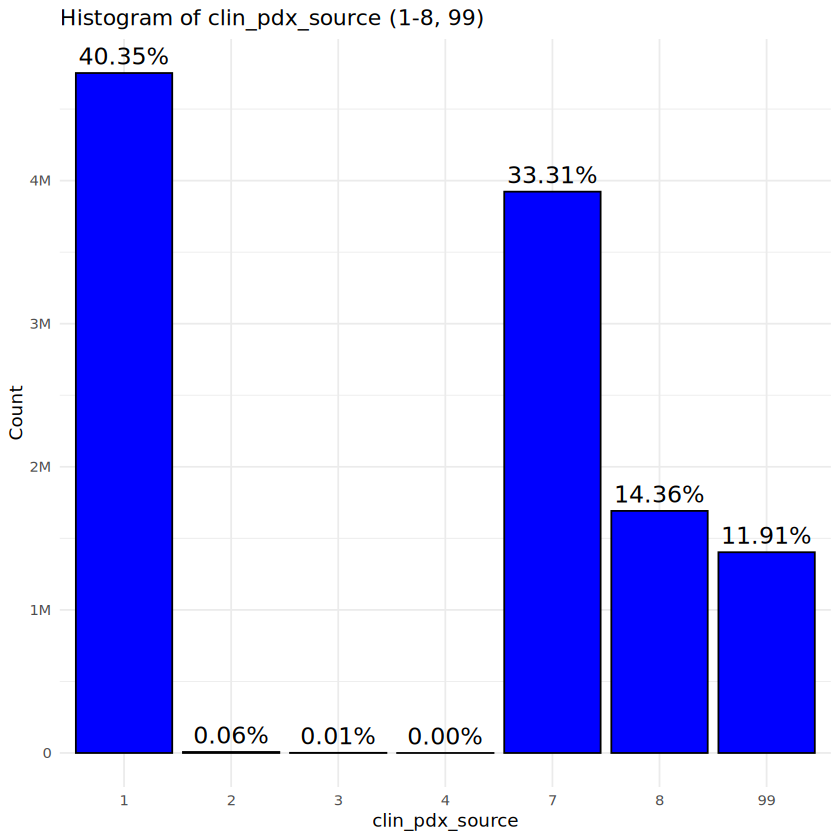

In [ ]:
# library(ggplot2)
# library(data.table)

# # Filter only the relevant values (1-8, 99)
# filtered_result <- result[clin_pdx_source %in% c(1:8, 99)]

# # Convert clin_pdx_source to a factor to remove gaps
# filtered_result[, clin_pdx_source := factor(clin_pdx_source, levels = c(1:8, 99))]

# # Compute counts and percentages
# counts <- filtered_result[, .N, by = clin_pdx_source] # Get count per category
# total_count <- sum(counts$N) # Compute total count
# counts[, label := sprintf("%.2f%%", (N / total_count) * 100)] # Convert to percentage

# # Create histogram with percentage labels
# ggplot(counts, aes(x = clin_pdx_source, y = N)) +
#   geom_bar(stat = "identity", fill = "blue", color = "black") + # Use geom_bar for precomputed counts
#   geom_text(aes(label = label), vjust = -0.5, size = 5) + # Add percentage labels above bars
#   labs(
#     title = "Histogram of clin_pdx_source (1-8, 99)",
#     x = "clin_pdx_source",
#     y = "Count"
#   ) +
#   scale_y_continuous(labels = scales::label_number(scale_cut = scales::cut_short_scale())) + # Format Y-axis with short notation
#   theme_minimal()


In [15]:
# BQ upload
if (to_bq) {
  # Define BQ table name concisely
  bq_table <- paste0(
    if (!to_create_std) "claims_" else "raw_claims_",
    year,
    if (!to_sample) "_" else suffix,
    if (!to_create_std) "v2" else ""
  )

  schema <- "bq_schema_cleaning.json"

  if (!to_automate) {
    # Construct full table reference
    table_ref <- sprintf("%s.%s.%s", gcp_proj, bq_dataset, bq_table)

    # User confirmation prompt
    message(sprintf("Do you want to overwrite the contents of: %s?", table_ref))
    overwrite <-
      readline(prompt = "Enter 'OVERWRITE' to proceed; any key to cancel: ")

    # Check response
    if (tolower(trimws(overwrite)) != "overwrite") {
      stop("Operation cancelled by the user.", call. = FALSE)
    }

    message("Proceeding with overwrite...")
  }

  # Attempt to delete the table if it exists
  tryCatch(
    bq_table_delete(bq_table(gcp_proj, bq_dataset, bq_table)),
    error = function(e) {
      if (grepl("Not found", e, ignore.case = TRUE)) {
        message("Table does not exist, nothing to drop.")
      } else {
        stop(e)
      }
    }
  )

  # Create the BQ table if it does not exist
  tryCatch(
    bq_table_create(
      bq_table(gcp_proj, bq_dataset, bq_table),
      fields = fromJSON(here(
        "data-cleaning/r_scripts_v2",
        schema
      ), simplifyDataFrame = FALSE)
    ),
    error = function(e) {
      if (grepl("already exists", e, ignore.case = TRUE)) {
        message("Table already exists. Skipping creation and upload.")
      } else {
        stop(e)
      }
    }
  )

  # Define chunk size for upload
  chunk_size <- 250000
  # Calculate number of chunks
  num_chunks <- ceiling(nrow(result) / chunk_size)

  for (i in seq_len(num_chunks)) {
    # Extract chunk
    chunk <- result[
      ((i - 1) * chunk_size + 1):min(i * chunk_size, nrow(result)),
    ]

    # Upload chunk to BQ
    bq_table_upload(
      bq_table(gcp_proj, bq_dataset, bq_table),
      values = chunk,
      write_disposition = if (i == 1) "WRITE_EMPTY" else "WRITE_APPEND"
    )
  }
} else {
  message("to_bq is FALSE, skipping BQ upload")
}


Do you want to overwrite the contents of: drg-pipeline.phic_claims.claims_2018_v2?

Proceeding with overwrite...

